# 06 · Scaling out: several GPUs, several vLLM servers

Phase 5 tuned one RTX 5090. This phase asks what happens with **several GPUs in one machine**: how well throughput scales with more vLLM servers, how NGINX should spread the load, whether splitting one model across GPUs beats running copies, what happens when a server dies under load, and what Mooncake adds once there's more than one server.

Every vLLM server runs the Phase 5 recommended config (**FP8 weights**). All numbers are read from `results/06_scaling_out/`.

## Setups

Run on **one machine with 2× RTX 5090** (no 4-GPU VM machine was available), so the curve is 1 → 2 GPUs. `scripts/topology.py` writes the Compose, NGINX and Prometheus config for each setup:

| Experiment | Setup | Traffic |
|---|---|---|
| Scaling | 1, 2 copies (one per GPU), round robin | Phase 4 mix; users scaled with the number of copies |
| Load balancing | 2 copies × round robin / least connections / sticky per user | **Conversations**: each user discusses a long document for 6 turns, so its prefix grows and repeats |
| Failover | 2 copies, least connections; one copy stopped under load for 90 s | Phase 4 mix |
| Tensor parallel | 1 server split across 2 GPUs | Same as the 2 copy run |
| Mooncake store | 2 copies, round robin, one KV store shared through Mooncake | Conversations |
| Disaggregated | 1 prefill + 1 decode server, KV handed over by Mooncake | Same as the 2 copy run |

The gateway runs 8 worker processes here: in Phase 4 one process used 84% of a core at ~6,000 tokens/s, and two GPUs produce ~16,000.

**Note on KV cache %:** Prometheus sums the KV usage gauge across servers, so with 2 servers 200% means both full. Tables below divide by the number of servers.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = ROOT / "results" / "06_scaling_out"
sys.path.insert(0, str(ROOT / "loadtest"))
from results_logger import load_runs, summarize

runs = load_runs("06_scaling_out")
sweeps = {r["config"]["label"]: r for r in runs if r["name"].startswith("load_sweep_")}
evals = {r["config"]["label"]: r for r in runs if r["name"].startswith("evals_")}
timeline = next((r for r in reversed(runs) if r["name"].startswith("timeline_")), None)
print(f"sweeps: {sorted(sweeps)}\nevals: {sorted(evals)} | failover timeline: {bool(timeline)}")
for f in sorted(RESULTS.glob("failed_*.log")):
    print(f"DID NOT START: {f.name}")
if sweeps:
    env = next(iter(sweeps.values()))["environment"]
    print(f"GPUs: {len(env['gpus'])} × {env['gpus'][0]['name'] if env['gpus'] else '?'}")

def v(d, *keys):
    for k in keys:
        d = (d or {}).get(k)
    return d

def cell(value, fmt, width, scale=1, unit=""):
    return ("-" if value is None else format(value * scale, fmt) + unit).rjust(width)

def n_servers(label):
    t = sweeps[label]["config"].get("topology") or ""
    return int(t.split("x")[0]) if t[:1].isdigit() else 2

def sweep_table(label):
    print(f"{label}  ({sweeps[label]['config'].get('topology')})")
    print(f"{'users':>7}{'tok/s':>8}{'TTFT p95':>11}{'ITL p50':>10}{'running':>9}{'waiting':>9}{'KV max':>8}{'errors':>8}")
    for s in sweeps[label]["metrics"]["steps"]:
        sv = s.get("server", {})
        print(f"{s['users']:>7}{cell(sv.get('output_tokens_per_s'), '.0f', 8)}{cell(s['ttft_s']['p95'], '.0f', 11, 1000, 'ms')}"
              f"{cell(s['itl_s']['p50'], '.1f', 10, 1000, 'ms')}{cell(v(sv, 'running', 'avg'), '.0f', 9)}"
              f"{cell(v(sv, 'waiting', 'max'), '.0f', 9)}{cell((v(sv, 'kv_cache_usage', 'max') or 0) / n_servers(label), '.0%', 8)}{s['errors']:>8}")
    print()

sweeps: ['lb_least_conn', 'lb_round_robin', 'lb_round_robin_mooncake', 'lb_user_hash', 'scale_1x', 'scale_2x', 'tp2']
evals: ['quality_tp2'] | failover timeline: True
GPUs: 2 × NVIDIA GeForce RTX 5090


## The NGINX incident (before the main runs)

The first 2-copy run had **1,574 errors (502)** at 768 users, all within about 100 seconds, and running requests stuck at ~350 instead of 512. NGINX logged *"no live upstreams"*: it had decided both healthy servers were dead. Two settings combined: vLLM's web server closes idle connections after 5 s while NGINX kept them up to 60 s, so under load NGINX occasionally reused a closed connection and got "connection reset"; and `max_fails=1` benched a server for 5 s after a single such failure. With 2 servers, a few resets benched both. Fix: `keepalive_timeout 4s` in the upstream (close first) and `max_fails=3`. The run was repeated from the 2-copy step; the original is kept in `results/06_discarded/`.

In [2]:
import glob
bad = sorted((ROOT / "results" / "06_discarded").glob("*load_sweep_scale_2x.json"))
if bad:
    d = json.loads(bad[0].read_text())
    print("before the fix (discarded run):")
    for s in d["metrics"]["steps"]:
        print(f"  {s['users']:>5} users  {v(s, 'server', 'output_tokens_per_s'):>7.0f} tok/s  running {v(s, 'server', 'running', 'avg'):>4.0f}  errors {s['errors']}")

before the fix (discarded run):
    128 users    12033 tok/s  running  123  errors 0
    256 users    16033 tok/s  running  242  errors 0
    384 users    15183 tok/s  running  342  errors 1
    512 users    14218 tok/s  running  347  errors 0
    768 users    14426 tok/s  running  373  errors 1574
   1024 users    12886 tok/s  running  331  errors 1


## 1. Scaling: 1 → 2 → 4 copies

In [3]:
scale = [l for l in ("scale_1x", "scale_2x", "scale_4x") if l in sweeps]
for l in scale:
    sweep_table(l)

scale_1x  (1x tp1 tune_fp8_weights lb=round_robin)
  users   tok/s   TTFT p95   ITL p50  running  waiting  KV max  errors
     64    6185      139ms    10.0ms       62        0      9%       0
    128    8717      322ms    13.7ms      122        0     16%       0
    192    8542      667ms    20.7ms      176        0     24%       0
    256    8365     1010ms    28.9ms      239        1     32%       0
    384    7304     4338ms    35.5ms      254      126     32%       0
    512    7304     8720ms    34.9ms      255      255     35%       0

scale_2x  (2x tp1 tune_fp8_weights lb=round_robin)
  users   tok/s   TTFT p95   ITL p50  running  waiting  KV max  errors
    128   12029      156ms    10.3ms      124        0      8%       0
    256   16022      402ms    15.0ms      243        0     16%       0
    384   15740      757ms    24.3ms      362        0     25%       0
    512   15208     3105ms    31.6ms      433       96     30%       0
    768   14230     7774ms    35.6ms      510

setup      GPUs  peak tok/s   per GPU  speedup  efficiency
scale_1x      1        8717      8717    1.00×       100%   (at 128 users)
scale_2x      2       16022      8011    1.84×        92%   (at 256 users)


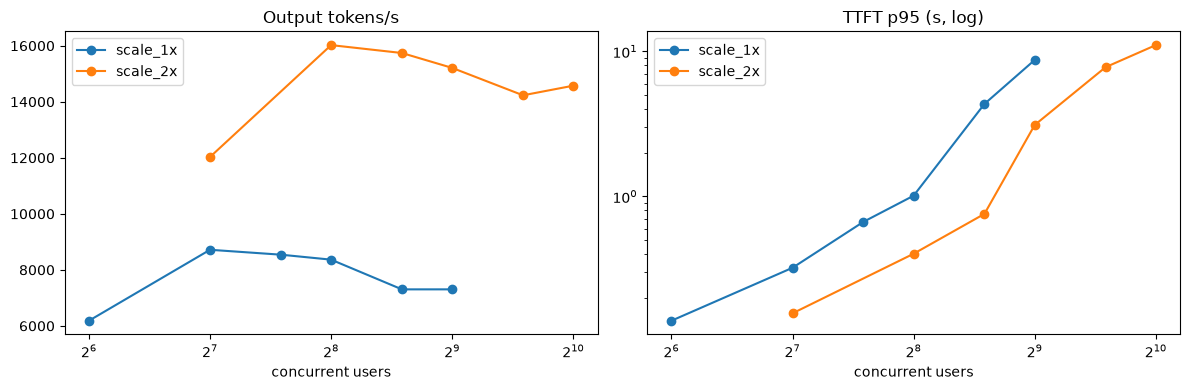

In [4]:
def peak(label):
    steps = sweeps[label]["metrics"]["steps"]
    best = max(steps, key=lambda s: v(s, "server", "output_tokens_per_s") or 0)
    return v(best, "server", "output_tokens_per_s"), best["users"]

if scale:
    base = peak("scale_1x")[0] if "scale_1x" in sweeps else None
    print(f"{'setup':<10}{'GPUs':>5}{'peak tok/s':>12}{'per GPU':>10}{'speedup':>9}{'efficiency':>12}")
    for l in scale:
        n = int(l.split("_")[1].rstrip("x"))
        p, users = peak(l)
        print(f"{l:<10}{n:>5}{p:>12.0f}{p / n:>10.0f}{(p / base if base else 0):>8.2f}×{(p / base / n if base else 0):>11.0%}   (at {users} users)")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for l in scale:
        steps = sweeps[l]["metrics"]["steps"]
        axes[0].plot([s["users"] for s in steps], [v(s, "server", "output_tokens_per_s") for s in steps], "o-", label=l)
        axes[1].plot([s["users"] for s in steps], [s["ttft_s"]["p95"] for s in steps], "o-", label=l)
    axes[0].set_title("Output tokens/s"); axes[1].set_title("TTFT p95 (s, log)"); axes[1].set_yscale("log")
    for ax in axes:
        ax.set_xscale("log", base=2); ax.set_xlabel("concurrent users"); ax.legend()
    plt.tight_layout(); plt.show()

## 2. Load balancing with conversations

Each user holds a 6-turn conversation about a long document, so every request repeats that user's growing prefix. Sticky routing (`hash $http_x_user_id`) keeps a user on one server, where the prefix is already cached; round robin and least connections spread a user's turns over all four.

In [5]:
lbs = [l for l in ("lb_round_robin", "lb_least_conn", "lb_user_hash", "lb_round_robin_mooncake") if l in sweeps]
if lbs:
    print(f"{'setup':<26}{'users':>6}{'tok/s':>8}{'TTFT p50':>10}{'TTFT p95':>10}{'prefix hit':>12}{'Mooncake hit':>14}{'preempt':>9}   running per server")
    for l in lbs:
        for s in sweeps[l]["metrics"]["steps"]:
            sv = s.get("server", {})
            per = sv.get("running_per_replica") or {}
            print(f"{l:<26}{s['users']:>6}{cell(sv.get('output_tokens_per_s'), '.0f', 8)}{cell(s['ttft_s']['p50'], '.0f', 10, 1000, 'ms')}"
                  f"{cell(s['ttft_s']['p95'], '.0f', 10, 1000, 'ms')}{cell(sv.get('prefix_cache_hit_rate'), '.0%', 12)}"
                  f"{cell(sv.get('external_cache_hit_rate'), '.1%', 14)}{cell(sv.get('preemptions'), '.0f', 9)}   " + " ".join(f"{per[k]:.0f}" for k in sorted(per)))
    print("\nTTFT p95 by request type (opening a conversation vs a follow-up turn), last step:")
    for l in lbs:
        last = sweeps[l]["metrics"]["steps"][-1]
        print(f"  {l:<26}" + "   ".join(f"{c}: {cell(x.get('ttft_p95_s'), '.0f', 0, 1000, 'ms')}" for c, x in sorted(last["by_category"].items())))

setup                      users   tok/s  TTFT p50  TTFT p95  prefix hit  Mooncake hit  preempt   running per server
lb_round_robin               256    6401     225ms     623ms         69%          0.0%        0   85 91
lb_round_robin               512    5390     256ms   11813ms         48%          0.0%        0   193 92
lb_least_conn                256    8563     326ms     572ms         71%          0.0%        0   78 78
lb_least_conn                512    6856     493ms    1207ms         68%          0.0%        0   205 198
lb_user_hash                 256    6392     221ms     653ms         68%          0.0%        0   76 90
lb_user_hash                 512    5810     242ms   11123ms         48%          0.0%        0   184 91
lb_round_robin_mooncake      256    4217     328ms   29536ms         69%          2.0%      507   62 66
lb_round_robin_mooncake      512    1840   26725ms   27730ms         37%          3.2%      783   34 19

TTFT p95 by request type (opening a conversati

## 3. Failover: one server stopped under load

15906 requests, 127 errors
  58 s: stop vllm-1
  150 s: start vllm-1


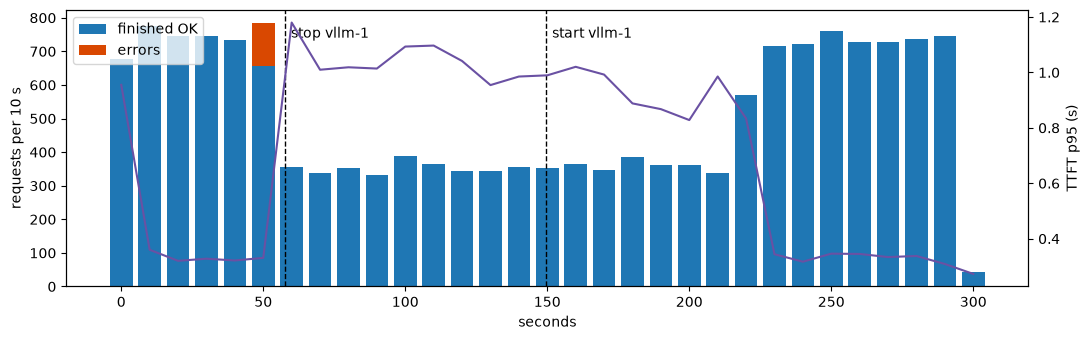

  50 s: 127 errors, e.g. ['<html>\r\n<head><title>502 Bad Gateway</title></head>\r\n<body>\r\n<center><h1>502 Bad', 'ChunkedEncodingError: Response ended prematurely']


In [6]:
if timeline:
    m = timeline["metrics"]
    tl = m["timeline"]
    print(f"{m['requests']} requests, {m['errors']} errors")
    for e in m["events"]:
        print(f"  {e['t_s']:.0f} s: {e['event']}")
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.bar([b["t_s"] for b in tl], [b["ok"] for b in tl], width=8, label="finished OK")
    ax.bar([b["t_s"] for b in tl], [b["errors"] for b in tl], width=8, bottom=[b["ok"] for b in tl], color="#d94801", label="errors")
    for e in m["events"]:
        ax.axvline(e["t_s"], color="black", ls="--", lw=1); ax.text(e["t_s"] + 2, ax.get_ylim()[1] * 0.9, e["event"])
    ax2 = ax.twinx(); ax2.plot([b["t_s"] for b in tl], [b["ttft_p95_s"] for b in tl], color="#6a51a3", label="TTFT p95")
    ax2.set_ylabel("TTFT p95 (s)"); ax.set_xlabel("seconds"); ax.set_ylabel("requests per 10 s"); ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()
    for b in tl:
        if b["errors"]:
            print(f"  {b['t_s']:.0f} s: {b['errors']} errors, e.g. {b['error_samples'][:2]}")
else:
    print("No failover run.")

## 4. Tensor parallel vs copies

In [7]:
pairs = [(a, b) for a, b in (("scale_2x", "tp2"), ("scale_4x", "tp4")) if a in sweeps and b in sweeps]
for a, b in pairs:
    print(f"{'users':>7}{a + ' tok/s':>16}{b + ' tok/s':>14}{a + ' TTFT p95':>18}{b + ' TTFT p95':>16}{a + ' ITL p50':>17}{b + ' ITL p50':>15}")
    sb = {s["users"]: s for s in sweeps[b]["metrics"]["steps"]}
    for s in sweeps[a]["metrics"]["steps"]:
        t = sb.get(s["users"], {})
        print(f"{s['users']:>7}{cell(v(s, 'server', 'output_tokens_per_s'), '.0f', 16)}{cell(v(t, 'server', 'output_tokens_per_s'), '.0f', 14)}"
              f"{cell(s['ttft_s']['p95'], '.0f', 18, 1000, 'ms')}{cell(v(t, 'ttft_s', 'p95'), '.0f', 16, 1000, 'ms')}"
              f"{cell(s['itl_s']['p50'], '.1f', 17, 1000, 'ms')}{cell(v(t, 'itl_s', 'p50'), '.1f', 15, 1000, 'ms')}")
    print()
if not pairs:
    print("No tensor parallel runs.")

  users  scale_2x tok/s     tp2 tok/s scale_2x TTFT p95    tp2 TTFT p95 scale_2x ITL p50    tp2 ITL p50
    128           12029          1117             156ms           648ms           10.3ms        115.5ms
    256           16022          1156             402ms          1048ms           15.0ms        201.2ms
    384           15740          1288             757ms         23312ms           24.3ms        201.9ms
    512           15208          1235            3105ms         43379ms           31.6ms        215.3ms
    768           14230          1177            7774ms               -           35.6ms              -
   1024           14573          1220           11043ms               -           34.9ms              -



## 5. Disaggregated prefill and decode

The 1 prefill + 1 decode setup started (both servers, the proxy and the Mooncake handshake came up), but **the decode server's engine crashed** while serving: an assertion inside vLLM 0.30.0's scheduler, `assert req_id in self.requests` in `_update_from_kv_xfer_finished`, i.e. a KV transfer finished for a request the scheduler no longer had. The log is in `results/06_scaling_out/pd_1p1d_engine_crash.log`. It wasn't debugged further on paid GPU time.

In [8]:
crash = RESULTS / "pd_1p1d_engine_crash.log"
if crash.exists():
    lines = [l for l in crash.read_text().splitlines() if "vllm-decode-0" in l and ("AssertionError" in l or "assert req_id" in l or "_update_from_kv_xfer_finished" in l)]
    print("\n".join(l.split("|", 1)[-1].strip()[:160] for l in lines[:4]))

(EngineCore pid=308) ERROR 10-05 16:15:38 [core.py:1368]     self._update_from_kv_xfer_finished(kv_connector_output)
(EngineCore pid=308) ERROR 10-05 16:15:38 [core.py:1368]   File "/usr/local/lib/python3.12/dist-packages/vllm/v1/core/sched/scheduler.py", line 3015, in _update
(EngineCore pid=308) ERROR 10-05 16:15:38 [core.py:1368]     assert req_id in self.requests
(EngineCore pid=308) ERROR 10-05 16:15:38 [core.py:1368] AssertionError


## Answer quality on the new setups

The 22-case eval set from Phase 3 on the setups that change how the model computes (tensor parallel splits every matrix multiply across GPUs; disaggregated serving moves the KV cache between servers). Phase 5's single-GPU FP8 weights result was 21 of 22.

In [9]:
for l, r in sorted(evals.items()):
    s = r["metrics"]["summary"]
    print(f"{l:<22}{s['passed']}/{s['total']}   " + ", ".join(f"{k} {x['passed']}/{x['total']}" for k, x in s["by_category"].items()))
    for c in r["metrics"]["cases"]:
        if not c["passed"]:
            print(f"     FAIL {c['id']:<22} {c['result']['content'][:80]!r}")

quality_tp2           21/22   correctness 7/7, instructions 5/5, summarization 0/1, safety 3/3, harness 6/6
     FAIL summary_incident       '- At 09:12 UTC, the payments API experienced elevated error rates and increased '


## Grafana

The whole session on one timeline (11:15 to 12:30): the 502 spike before the NGINX fix (~11:31), the scaling and load balancing runs (11:30 to 11:50), the failover drill, tensor parallel (~12:00, inter token latency 400 to 800 ms), and the Mooncake store run (~12:25, about 1,500 preemptions a minute).

![Latency](images/06_scaling_out/grafana_1_latency.png)

![Traffic](images/06_scaling_out/grafana_2_traffic.png)

![Engine capacity](images/06_scaling_out/grafana_3_engine_capacity.png)

![GPU](images/06_scaling_out/grafana_4_gpu.png)

![KV cache tiers](images/06_scaling_out/grafana_5_kv_cache_tiers.png)

![Harnesses](images/06_scaling_out/grafana_6_harnesses.png)

## What happened

**1. Copies scale almost linearly: 2 GPUs gave 1.84× (92% efficiency).** One copy peaked at 8,717 output tokens/s (matching Phase 5's 8,662 on another machine), two at 16,022, with zero errors up to 1,024 users once NGINX was fixed. Both servers filled to their 255 request cap, and queueing started at 512 users instead of 256.

**2. Least connections is the right balancer: ~10× better tail latency than round robin at load.** On conversations at 512 users, round robin and sticky routing let one server fall behind and pile up (≈190 vs 90 requests running), with TTFT p95 of 11 to 12 s. Least connections kept both servers even (205 / 198) at 1.2 s, with 27% more throughput. Requests differ in length, so counting requests isn't balancing work. **Sticky routing gave no cache benefit with 2 servers**: round robin already returns a user to the same server half the time, and the imbalance it caused cost more (the overloaded server evicted prefixes, so the hit rate fell from 68% to 48%).

**3. A load balancer's health checks can cause the outage they're meant to prevent.** With `max_fails=1` and NGINX holding idle connections longer than vLLM, a few stale connection resets under load benched both healthy servers and produced 1,574 errors. Fixed by closing idle connections before vLLM does and requiring 3 failures.

**4. Failover works, and costs exactly the requests in flight.** Stopping one of two servers under load failed 127 requests (0.8%), all in the 10 seconds of the stop: streams already running on that server can't move. After that, zero errors; the survivor carried everything at half the throughput and ~1.1 s TTFT p95, and when the server came back (~70 s to load) NGINX picked it up without a restart and latency returned to 0.33 s.

**5. Tensor parallel across these 2 GPUs is ~13× slower than 2 copies.** ~1,200 tokens/s against 16,022, and slower than a single GPU. `nvidia-smi topo` shows the GPUs connected through the PCIe host bridge with peer-to-peer access *not supported*, so the two all-reduces per layer per token go through host memory inside a VM. Answers stayed correct (21/22). **On consumer GPUs without NVLink, run one copy per GPU and never split a model that fits on one.**

**6. A shared Mooncake store over TCP made concurrent serving much worse.** It wrote 29 GiB and served cross-server prefix hits, but throughput fell 34% at 256 users and 66% at 512, TTFT p95 rose to ~30 s, and the KV cache filled with 783 preemptions in a minute. vLLM keeps a block in GPU memory until it has been saved to the store, and TCP writes (~0.4 to 0.6 GiB/s) can't keep up with concurrent prefills, so pending saves crowd out running requests. Phase 2 found Mooncake helps a long prompt that returns after eviction at low load; under concurrent load on TCP it hurts.

**7. Disaggregated prefill/decode crashed inside vLLM** (an assertion in the KV transfer bookkeeping of vLLM 0.30.0's scheduler), so it couldn't be measured.

**Deployment recommendation for this hardware:** one FP8 weights copy per GPU, behind NGINX with least connections, `keepalive_timeout` shorter than vLLM's, and passive health checks that need several failures. No tensor parallel, and no Mooncake store without RDMA.

## Phase 6 exit criteria

- [x] Generated setups for N copies, tensor parallel, load balancing methods, a shared Mooncake store and disaggregated serving
- [x] Conversation load mode, per-server balance and prefix cache hit rate per step
- [x] Failover drill under load with a per-10-second timeline
- [x] Phase 6 session on a multi-GPU RTX 5090 machine (2 GPUs)
- [x] Scaling factor, best routing, failover behaviour and Mooncake results explained